# An example planet: TRAPPIST-1e

TRAPPIST-1e is a roughly Earth-sized planet orbiting a small, cool red-dwarf star about 40 light-years away. 
It is of particular interest to the exoplanet community because it is potentially habitable and [relatively favourable for observations](https://www.scientificamerican.com/article/jwst-sees-hints-of-an-atmosphere-on-a-potentially-habitable-exoplanet/). 
We have a few simulations of TRAPPIST-1e in ThousandWorlds, so it makes a good example to see what the outputs look like from various perspectives!

In [1]:
%matplotlib inline
import thousandworlds as tw
from thousandworlds import viz
import matplotlib.pyplot as plt

TRAPPIST-1e's planet parameters aren't perfectly known, so there's a few simulations with different inputs that are TRAPPIST-1e-adjacent. We'll just look at one here.

In [2]:
bundle = tw.load("multi-complete", data_dir="dataset")

# One of the TRAPPIST-1e-adjacent simulations in the benchmark
sim_id = 1620
idx = bundle.test_ids.tolist().index(sim_id)

m = bundle.meta_test.iloc[idx]
print(f"simulation_id={sim_id} (row {idx}, GCM: {m.gcm_label})")
print(f"  stellar temperature : {m.stellar_temperature:.0f} K")
print(f"  incident flux       : {m.stellar_flux:.0f} W/m^2")
print(f"  radius              : {m.radius / 6.371e6:.2f} R_earth")
print(f"  gravity             : {m.gravity:.1f} m/s^2")
print(f"  rotation period     : {m.rotation_period:.1f} days")
print(f"  surface pressure    : {m.surface_pressure / 1e5:.2f} bar")
print(f"  CO2 volume fraction : {m.co2:.2g}")
print(f"  CH4 volume fraction : {m.ch4:.2g}")
print(f"  source GCM          : {m.gcm_label}")

simulation_id=1620 (row 98, GCM: exocam)
  stellar temperature : 2600 K
  incident flux       : 900 W/m^2
  radius              : 0.91 R_earth
  gravity             : 9.1 m/s^2
  rotation period     : 6.1 days
  surface pressure    : 1.00 bar
  CO2 volume fraction : 0.0004
  CH4 volume fraction : 0
  source GCM          : exocam


## Surface temperature

Surface temperature is probably the most important field because of its implications for habitability. Since these planets always shows the same face to their host star, the centre of the (permanent-)dayside (the *substellar point*) is often the hottest point on the planet (although winds can shift this!), with the nightside much cooler. 

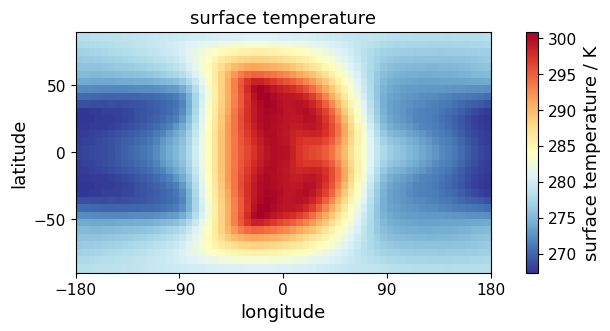

In [3]:
fig, _ = viz.field_map(bundle, idx, "surface_temperature", title="surface temperature")

## Winds

Let's have a look at the winds too. Here are wind streamlines at two levels, coloured by speed: near the surface (level 0) and the upper troposphere (~280 hPa, level 6)

Near the surface, air converges on the substellar point. In the upper troposhere it seems to becomes a broad eastward jet that carries heat to the night side.

(<Figure size 1100x280 with 4 Axes>,
 <Axes: title={'center': 'upper troposphere wind'}, xlabel='longitude', ylabel='latitude'>)

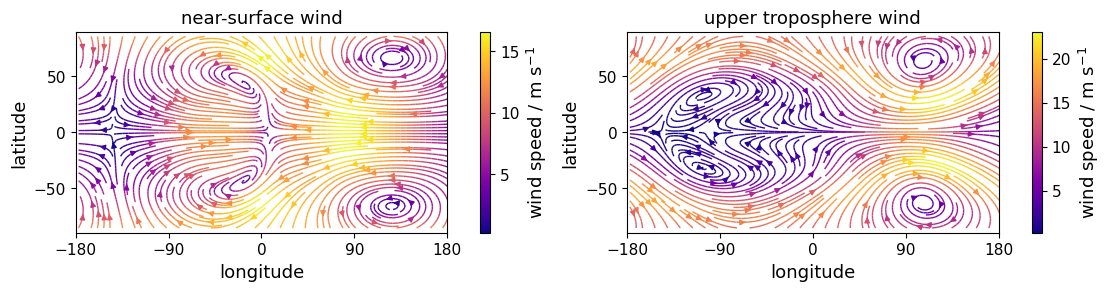

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 2.8), constrained_layout=True)
viz.wind_streamlines(bundle, idx, level=0, ax=axes[0], title="near-surface wind")
viz.wind_streamlines(bundle, idx, level=6, ax=axes[1], title="upper troposphere wind") # ~=280 hPa

## Clouds and humidity

And here is the near-surface cloud fraction and (specific) humidity - cloud fraction in particular can be quite 'sharp' (lots of power at high spatial frequencies)

(<Figure size 1100x280 with 4 Axes>,
 <Axes: title={'center': 'specific humidity (near-surface)'}, xlabel='longitude', ylabel='latitude'>)

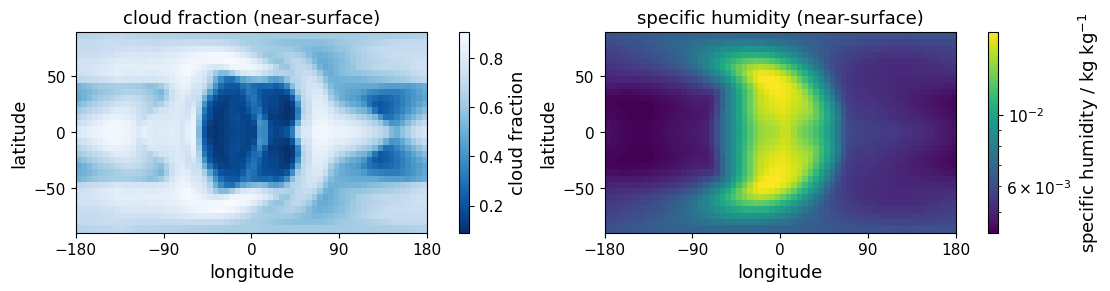

In [5]:
from matplotlib.colors import LogNorm
fig, axes = plt.subplots(1, 2, figsize=(11, 2.8), constrained_layout=True)
viz.field_map(bundle, idx, "cloud_fraction_0", ax=axes[0], title="cloud fraction (near-surface)")
viz.field_map(bundle, idx, "specific_humidity_0", ax=axes[1], title="specific humidity (near-surface)", norm=LogNorm())

## Vertical structure

But the climate is not just 2D - it also has vertical structure! Here is a latitude–pressure cross-section of the longitudinally-averaged temperature, and some 1D profiles (substellar point, antistellar point diametrically opposite, and the global mean).

We see that this climate's temperature gradually decreases and homogenizes higher in the atmosphere. 



(<Figure size 950x400 with 3 Axes>,
 <Axes: xlabel='temperature / K', ylabel='pressure / hPa'>)

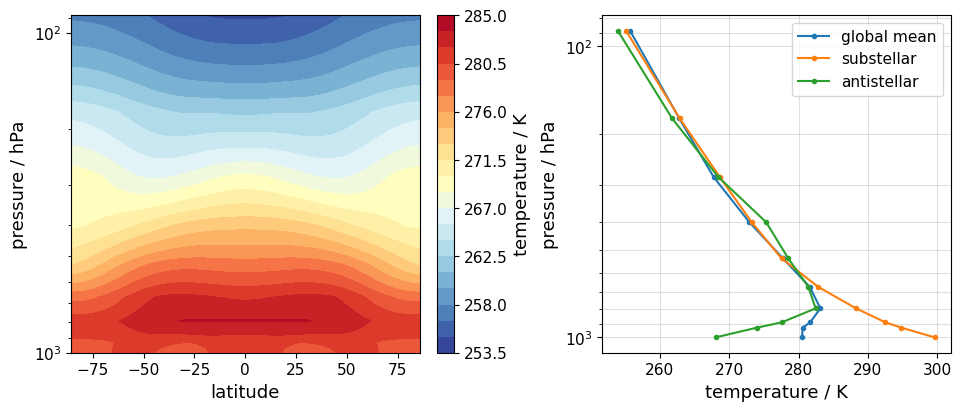

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(9.5, 4), constrained_layout=True)
viz.zonal_cross_section(bundle, idx, ax=axes[0])
viz.temperature_profile(bundle, idx, ax=axes[1])

## Radiation budget

The two radiation fields absorbed shortwave radiation (ASR) and outgoing longwave radiation (OLR) set the energy budget. ASR - OLR is the net radiative gain - here we see the characteristic net absorbing on the dayside and emitting on the nightside.

Notice how the ASR map echoes the cloud-fraction map above - a reminder that these fields can be highly correlated (which may affect your model architecture choices!)

(<Figure size 1600x280 with 6 Axes>,
 <Axes: title={'center': 'ASR − OLR'}, xlabel='longitude', ylabel='latitude'>)

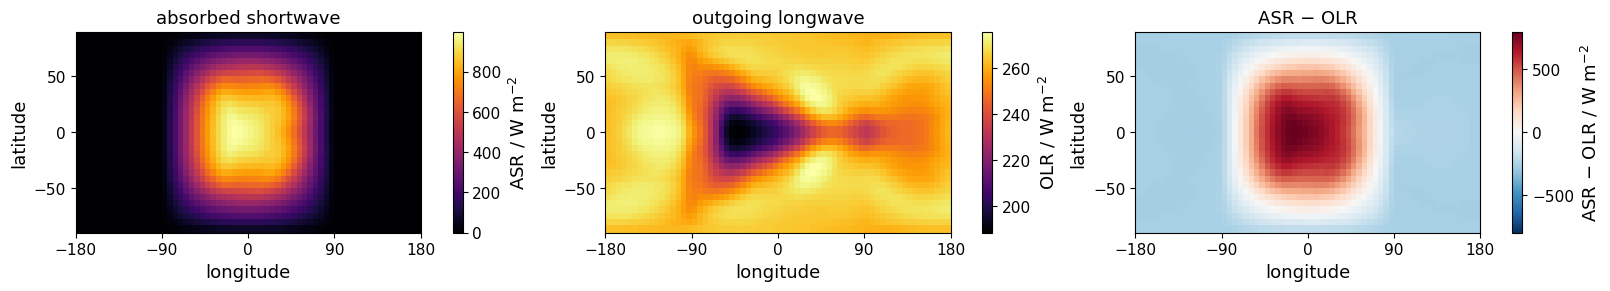

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 2.8), constrained_layout=True)
viz.field_map(bundle, idx, "asr", ax=axes[0], title="absorbed shortwave")
viz.field_map(bundle, idx, "olr", ax=axes[1], title="outgoing longwave")
viz.net_radiation_map(bundle, idx, ax=axes[2], title="ASR − OLR")

---
Every panel above is raw simulation output for just **one** world. ThousandWorlds holds over a thousand! Try another planet and see what changes!